In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv( 'uber_processed.csv')

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False


In [2]:
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error   
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import PolynomialFeatures
    x = df.drop( columns = 'mpg')
    y = df[ 'mpg' ]
    xTemp, xTest,   yTemp, yTest = train_test_split ( x, y, test_size = 0.15, random_state = 42 )
    xTrain, xVal, yTrain, yVal = train_test_split ( xTemp, yTemp, test_size = 0.15/0.85, random_state = 42 )

    scaler = StandardScaler()
    xTrainScaled = scaler.fit_transform(xTrain)
    xValScaled = scaler.transform(xVal)
    xTestScaled = scaler.transform(xTest)


In [11]:
degrees = [ 2, 3, 4, 5]
trainRmselist = []
valRmseList   = []
trainRsqlist  = []
valRsqlist    = []

for degree in degrees:
    poly = PolynomialFeatures( degree = degree, include_bias = False )
    xTrainPoly = poly.fit_transform(xTrainScaled)
    xValPoly   = poly.transform(xValScaled)
    xTestPoly  = poly.transform(xTestScaled)

    model = LinearRegression().fit(xTrainPoly,yTrain)

    trainPredsPoly = model.predict ( xTrainPoly )
    valPredsPoly   = model.predict ( xValPoly )

    trainRmse = np.sqrt( mean_squared_error ( yTrain, trainPredsPoly ))
    valRmse   = np.sqrt( mean_squared_error ( yVal, valPredsPoly ))

    trainRsq = r2_score ( yTrain, trainPredsPoly ) 
    valRsq   = r2_score ( yVal, valPredsPoly )
    
    trainRmselist.append(trainRmse)
    valRmseList.append(valRmse)
    trainRsqlist.append(trainRsq)
    valRsqlist.append(valRsq)
    
    print(f"Degree {degree}: Train RMSE={trainRmse:.4f}, Val RMSE={valRmse:.4f}, "
          f"Train R²={trainRsq:.4f}, Val R²={valRsq:.4f}") 

Degree 2: Train RMSE=2.4494, Val RMSE=2.9807, Train R²=0.9023, Val R²=0.8503
Degree 3: Train RMSE=1.5202, Val RMSE=15.1559, Train R²=0.9624, Val R²=-2.8700
Degree 4: Train RMSE=0.0000, Val RMSE=99.6884, Train R²=1.0000, Val R²=-166.4336
Degree 5: Train RMSE=0.0000, Val RMSE=55.4049, Train R²=1.0000, Val R²=-50.7190


It seems like degree 2 is the sweet spot model

degree onwards the models overfit really bad reaching rmse of 0 on training data even then exploding to 99 on valdiation data data.
 
 # NOW its time to test lasso and ridge regression on the poly of degree 2

In [14]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso

bestDegree = 2

poly = PolynomialFeatures (degree= bestDegree, include_bias = False )
xTrainPoly = poly.fit_transform(xTrainScaled)
xValPoly   = poly.transform(xValScaled)
xTestPoly  = poly.transform(xTestScaled)
xTrainValPoly = np.vstack([xTrainPoly, xValPoly])
yTrainVal     = np.concatenate([yTrain, yVal])

alphas = { 'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000] }

ridgeGrid = GridSearchCV( Ridge(), alphas, cv = 5, scoring = 'neg_mean_squared_error' )
ridgeGrid.fit ( xTrainValPoly, yTrainVal )
bestRidgeAlpha = ridgeGrid.best_params_['alpha']
ridgeModel = Ridge( alpha = bestRidgeAlpha ).fit( xTrainValPoly, yTrainVal )


lassoGrid = GridSearchCV(Lasso(max_iter=10000), alphas, cv=5, scoring='neg_mean_squared_error')
lassoGrid.fit(xTrainValPoly, yTrainVal)
bestLassoAlpha = lassoGrid.best_params_['alpha']
lassoModel = Lasso(alpha=bestLassoAlpha, max_iter=10000).fit(xTrainValPoly, yTrainVal)

print(f"Best Ridge alpha: {bestRidgeAlpha}")
print(f"Best Lasso alpha: {bestLassoAlpha}")

Best Ridge alpha: 10
Best Lasso alpha: 0.1


In [ ]:
Those are the alpha values that provide the best minization

In [15]:
for name, model in [('Ridge', ridgeModel), ('Lasso', lassoModel)]:
    testPreds = model.predict(xTestPoly)
    testRmse  = np.sqrt(mean_squared_error(yTest, testPreds))
    testR2    = r2_score(yTest, testPreds)
    print(f"{name}: Test RMSE={testRmse:.4f}, Test R²={testR2:.4f}")



Ridge: Test RMSE=2.2642, Test R²=0.9124
Lasso: Test RMSE=2.2549, Test R²=0.9131


As we can see can see, both of them outperform the unregulazed Poly of degree 2 now lets compare them all  directly

In [16]:
unregModel = LinearRegression().fit(xTrainPoly, yTrain)
unregTestPreds = unregModel.predict(xTestPoly)
unregTestRmse  = np.sqrt(mean_squared_error(yTest, unregTestPreds))
unregTestR2    = r2_score(yTest, unregTestPreds)
print(f"Unregularized (LinearRegression): Test RMSE={unregTestRmse:.4f}, Test R²={unregTestR2:.4f}")

Unregularized (LinearRegression): Test RMSE=2.6122, Test R²=0.8834


The lasso model outperforms all the rest which makes sense as after making the degree of 2, there would be alot of redundant features like cylinders * country code which essentially means nothing, so its better to have those features reduced to 0

now lets compute MSE, MAE, MAPE FOR LASSO OF DEGREE 2

In [24]:
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error   
    
    testPreds = lassoModel.predict( xTestPoly )
    bestMse  =  mean_squared_error ( yTest, testPreds )
    bestMae  =  mean_absolute_error( yTest, testPreds )
    bestMape = mean_absolute_percentage_error(yTest, testPreds )
    print ( f"MSE: {bestMse}" )
    print ( f"MAE: {bestMae}" )
    print ( f"MAPE: {bestMape}" )




MSE: 5.084366292465174
MAE: 1.6439647778894357
MAPE: 0.0705406880834661


applying step 6 : checking whether resduals give a shape or randomly scattered which would suggest hetroscedasity

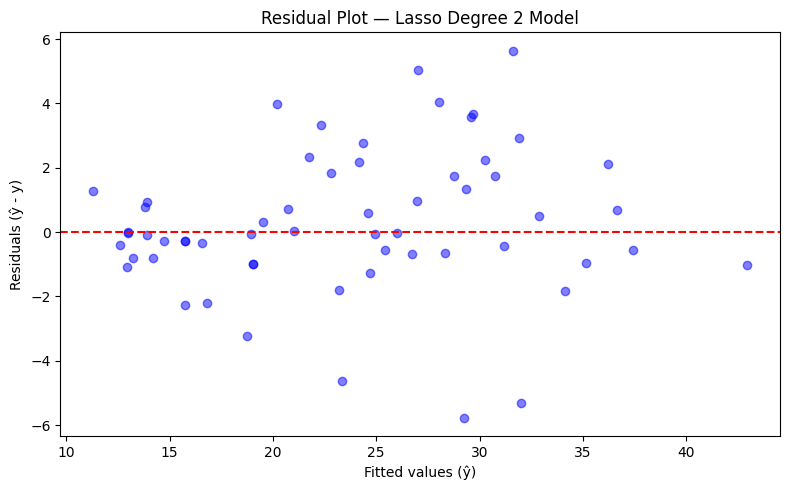

In [25]:
testPreds = lassoModel.predict(xTestPoly)
residuals = testPreds - yTest   # ŷ - y

plt.figure(figsize=(8, 5))
plt.scatter(testPreds, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted values (ŷ)')
plt.ylabel('Residuals (ŷ - y)')
plt.title('Residual Plot — Lasso Degree 2 Model')
plt.tight_layout()
plt.show()

No funnel shape. The spread of residuals doesn't systematically widen or narrow as fitted values increase — points are scattered with roughly similar vertical spread across the low, mid, and high fitted-value ranges (maybe very slightly wider in the 20-35 range, but nothing dramatic). This means no strong heteroscedasticity — your model's error variance is fairly consistent across the range of predictions.

Centered around zero. The red dashed line at y=0 has points scattered fairly evenly above and below it across the whole x-axis